# Football Data Analysis — Coruscant League 🌌⚽

Exploratory data analysis of a fictional football league dataset.

In [161]:
# Import required libraries
import pandas as pd
import numpy as np
import plotly.express as px

## Part 1: Data Loading and Exploration

**1)** Read the three corresponding CSV files: `goals.csv`, `players.csv` and `teams.csv`, and save them in dataframes with the same name.

In [162]:
goals = pd.read_csv("/Users/_/goals.csv")

In [163]:
players = pd.read_csv("/Users/_/players.csv")

In [164]:
teams = pd.read_csv("/Users/_/teams.csv")

**2)** Check the data types of the three dataframes and the statistical description of the numerical goal data.

In [165]:
goals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2490 entries, 0 to 2489
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2490 non-null   int64  
 1   date              2490 non-null   object 
 2   home_team         2490 non-null   object 
 3   away_team         2490 non-null   object 
 4   tournament        2490 non-null   object 
 5   friendly          2490 non-null   int64  
 6   goal_timestamp    2490 non-null   object 
 7   goal_scorer_id    2490 non-null   int64  
 8   goal_scorer_team  2490 non-null   object 
 9   xg                2490 non-null   float64
 10  distance          2490 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 214.1+ KB


In [166]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   player_id           416 non-null    int64 
 1   player_name         416 non-null    object
 2   player_team_name    416 non-null    object
 3   player_nationality  416 non-null    object
 4   player_age          416 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 16.4+ KB


In [167]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   team_name           20 non-null     object
 1   team_location       20 non-null     object
 2   stadium_capacity    20 non-null     int64 
 3   last_year_position  20 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 772.0+ bytes


In [168]:
descripcion = goals.describe()

print(descripcion)

                id     friendly  goal_scorer_id           xg     distance
count  2490.000000  2490.000000     2490.000000  2490.000000  2490.000000
mean    219.027309     0.075904      185.226506     0.355745    19.605020
std     124.886005     0.264897      117.950297     0.183132     9.333532
min       1.000000     0.000000        1.000000     0.083000     4.000000
25%     110.000000     0.000000       80.000000     0.219250    11.500000
50%     218.000000     0.000000      174.000000     0.313000    19.400000
75%     327.000000     0.000000      280.000000     0.451000    27.600000
max     434.000000     1.000000      416.000000     0.970000    36.000000


**3)** Are there columns with null values in any of the three dataframes? If yes, in which columns and in which dataframes? If there are any, fill them in in a reasonable way.

In [ ]:
no

## Part 2: Data Processing

**4)** The `date` column of `goals` appears as a string. Convert it to type `datetime`. Do the same with `goal_timestamp`. Verify the change with `.dtypes`.

In [169]:
goals["date"] = pd.to_datetime(goals["date"])
goals["goal_timestamp"] = pd.to_datetime(goals["goal_timestamp"])
goals.head()

,id,date,home_team,away_team,tournament,friendly,goal_timestamp,goal_scorer_id,goal_scorer_team,xg,distance
0,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:06:00,210,Corellia FC,0.709,11.2
1,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:31:00,223,Corellia FC,0.102,29.3
2,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:14:00,223,Corellia FC,0.498,15.8
3,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:17:00,215,Corellia FC,0.140,23.6
4,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:51:00,349,Geonosis Giants,0.255,36.0


**5)** Create a `goal_minute` column in `goals` that represents the approximate minute the goal was scored within the match. To do this, calculate the difference in minutes between `goal_timestamp` and `date`, rounded to the nearest integer.

In [170]:
goals["goal_minute"] = (goals ["goal_timestamp"] - goals ["date"]).dt.total_seconds()/60
goals.head()


,id,date,home_team,away_team,tournament,friendly,goal_timestamp,goal_scorer_id,goal_scorer_team,xg,distance,goal_minute
0,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:06:00,210,Corellia FC,0.709,11.2,66.0
1,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:31:00,223,Corellia FC,0.102,29.3,31.0
2,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:14:00,223,Corellia FC,0.498,15.8,74.0
3,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:17:00,215,Corellia FC,0.140,23.6,17.0
4,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:51:00,349,Geonosis Giants,0.255,36.0,51.0


**6)** Create a function called `classify_period` that, given a minute, returns:
- `'1st half'` if the minute is less than or equal to 45
- `'2nd half'` if the minute is greater than 45

Then, using `np.vectorize` or `apply`, create a `period` column in `goals` with this classification.

In [171]:
def classify_period (goal_minute):

    if goal_minute > 45:

        return ('2do Tiempo')

    else:

        return ('1er Tiempo')

goals['period'] = goals['goal_minute'].apply(classify_period)


goals.head()

,id,date,home_team,away_team,tournament,friendly,goal_timestamp,goal_scorer_id,goal_scorer_team,xg,distance,goal_minute,period
0,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:06:00,210,Corellia FC,0.709,11.2,66.0,2do Tiempo
1,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:31:00,223,Corellia FC,0.102,29.3,31.0,1er Tiempo
2,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:14:00,223,Corellia FC,0.498,15.8,74.0,2do Tiempo
3,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:17:00,215,Corellia FC,0.140,23.6,17.0,1er Tiempo
4,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:51:00,349,Geonosis Giants,0.255,36.0,51.0,2do Tiempo


**7)** Merge the `goals` dataframe with `players` to add the scorer information (name, nationality, age) to each goal row. Use a left join based on `goals`. Override the `goals` dataframe.

In [172]:
goals = goals.merge(players,left_on = 'goal_scorer_id', right_on = 'player_id')
goals.head()

,id,date,home_team,away_team,tournament,friendly,goal_timestamp,goal_scorer_id,goal_scorer_team,xg,distance,goal_minute,period,player_id,player_name,player_team_name,player_nationality,player_age
0,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:06:00,210,Corellia FC,0.709,11.2,66.0,2do Tiempo,210,Sabine Kenobi,Corellia FC,Kashyyyk,18
1,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:31:00,223,Corellia FC,0.102,29.3,31.0,1er Tiempo,223,Kit Orrelios,Corellia FC,Endorian,26
2,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 19:14:00,223,Corellia FC,0.498,15.8,74.0,2do Tiempo,223,Kit Orrelios,Corellia FC,Endorian,26
3,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:17:00,215,Corellia FC,0.140,23.6,17.0,1er Tiempo,215,Kira Tane,Corellia FC,Kaminoan,36
4,1,2025-08-01 18:00:00,Corellia FC,Geonosis Giants,Liga Coruscant,0,2025-08-01 18:51:00,349,Geonosis Giants,0.255,36.0,51.0,2do Tiempo,349,Even Tane,Geonosis Giants,Tatooinean,30


## Part 3: Standings

**8)** Using `goals`, create the standings table for the **Coruscant League** (excluding friendlies and the Galactic Cup). To do this:

a) Filter `goals` to include only Coruscant League matches.

b) Obtain a dataframe with one row per match (a unique combination of `id`, `home_team`, and `away_team`).

c) Calculate the goals scored by each team per match: perform a groupby operation using `id` and `goal_scorer_team`, counting rows, and merge this information back into the match dataframe.

d) Calculate points: 3 for a win, 1 for a draw, and 0 for a loss, for both the home and away teams.

e) Create the final table with the following columns: `team`, `PJ`, `W`, `D`, `L`, `GF`, `GA`, `DIF`, and `Pts`, ordered by points from highest to lowest.

*Tip: You can use a "long table" approach by creating separate rows for local and visitor before adding them.*

In [173]:
# a) Filter only Coruscant League matches

goals_liga = goals[goals['tournament'] == 'Liga Coruscant']
goals_liga.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2178 entries, 0 to 2177
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  2178 non-null   int64         
 1   date                2178 non-null   datetime64[ns]
 2   home_team           2178 non-null   object        
 3   away_team           2178 non-null   object        
 4   tournament          2178 non-null   object        
 5   friendly            2178 non-null   int64         
 6   goal_timestamp      2178 non-null   datetime64[ns]
 7   goal_scorer_id      2178 non-null   int64         
 8   goal_scorer_team    2178 non-null   object        
 9   xg                  2178 non-null   float64       
 10  distance            2178 non-null   float64       
 11  goal_minute         2178 non-null   float64       
 12  period              2178 non-null   object        
 13  player_id           2178 non-null   int64         
 1

In [174]:
# b) Get a dataframe with one row per match (unique combination of id, home_team, away_team).

fila_por_partido = goals_liga[['id','home_team','away_team']]
fila_por_partido = fila_por_partido.groupby('id').first().reset_index()

fila_por_partido.head()

,id,home_team,away_team
0,1,Corellia FC,Geonosis Giants
1,2,Galactic Senate United,Dagobah United
2,3,Kamino Tides,Senate District Athletic
3,4,Lothal Lions,Lower Levels FC
4,5,Mandalorian Warriors,Kashyyyk Wanderers


In [175]:
# c) Calculate goals per team per match: groupby id and goal_scorer_team counting rows, then merge back to the matches dataframe.


fila_por_partido = goals_liga[['id', 'home_team', 'away_team']].groupby('id').first().reset_index()

goles_cada_equipo = goals_liga.groupby(['id', 'goal_scorer_team']).size().reset_index(name='goles')

# Home team goals, named home_goals to follow the home_team convention
fila_por_partido = fila_por_partido.merge(goles_cada_equipo, left_on=['id', 'home_team'], right_on=['id', 'goal_scorer_team'], how='left').rename(columns={'goles': 'home_goals'}).drop(columns='goal_scorer_team', errors='ignore')

# Away team goals, named away_goals to follow the away_team convention
fila_por_partido = fila_por_partido.merge(goles_cada_equipo, left_on=['id', 'away_team'], right_on=['id', 'goal_scorer_team'], how='left').rename(columns={'goles': 'away_goals'}).drop(columns='goal_scorer_team', errors='ignore')

fila_por_partido[['home_goals', 'away_goals']] = fila_por_partido[['home_goals', 'away_goals']].fillna(0).astype(int)

fila_por_partido.head()

,id,home_team,away_team,home_goals,away_goals
0,1,Corellia FC,Geonosis Giants,4,1
1,2,Galactic Senate United,Dagobah United,3,3
2,3,Kamino Tides,Senate District Athletic,1,3
3,4,Lothal Lions,Lower Levels FC,1,3
4,5,Mandalorian Warriors,Kashyyyk Wanderers,2,2


In [176]:
# d) Calculate points: 3 for win, 1 for draw, 0 for loss, for both home and away teams.

def puntos (home_goals,away_goals):

    if home_goals > away_goals:

        return 3, 0
    
    elif home_goals < away_goals:

        return 0, 3

    else: 
        
        return 1, 1

fila_por_partido[['home_points', 'away_points']] = fila_por_partido.apply(lambda row: puntos(row['home_goals'], row['away_goals']), axis=1, result_type='expand')

fila_por_partido.head()



,id,home_team,away_team,home_goals,away_goals,home_points,away_points
0,1,Corellia FC,Geonosis Giants,4,1,3,0
1,2,Galactic Senate United,Dagobah United,3,3,1,1
2,3,Kamino Tides,Senate District Athletic,1,3,0,3
3,4,Lothal Lions,Lower Levels FC,1,3,0,3
4,5,Mandalorian Warriors,Kashyyyk Wanderers,2,2,1,1


In [177]:
# e) Build the final standings table with columns: team, MP, W, D, L, GF, GA, GD, Pts, sorted by points descending.

# Local x cada equipo
home_tabla = fila_por_partido.groupby('home_team').agg(
    pj_local=('id', 'count'),
    pts_local=('home_points', 'sum'),
    gf_local=('home_goals', 'sum'),
    ga_local=('away_goals', 'sum'),
    pg_local=('home_points', lambda x: (x==3).sum()),
    pp_local=('home_points', lambda x: (x==0).sum()),
    pe_local=('home_points', lambda x: (x==1).sum())
).reset_index()

# Visitante x cada equipo
away_tabla = fila_por_partido.groupby('away_team').agg(
    pj_visitante=('id', 'count'),
    pts_visitante=('away_points', 'sum'),
    gf_visitante=('away_goals', 'sum'),
    ga_visitante=('home_goals', 'sum'),
    pg_visitante=('away_points', lambda x: (x==3).sum()),
    pp_visitante=('away_points', lambda x: (x==0).sum()),
    pe_visitante=('away_points', lambda x: (x==1).sum())
).reset_index()

# Uno local y visitante
tabla_posiciones = home_tabla.merge(away_tabla, left_on='home_team', right_on='away_team', how='outer')

# Totales
tabla_posiciones['PJ'] = tabla_posiciones['pj_local'] + tabla_posiciones['pj_visitante']
tabla_posiciones['PG'] = tabla_posiciones['pg_local'] + tabla_posiciones['pg_visitante']
tabla_posiciones['PE'] = tabla_posiciones['pe_local'] + tabla_posiciones['pe_visitante']
tabla_posiciones['PP'] = tabla_posiciones['pp_local'] + tabla_posiciones['pp_visitante']
tabla_posiciones['GF'] = tabla_posiciones['gf_local'] + tabla_posiciones['gf_visitante']
tabla_posiciones['GA'] = tabla_posiciones['ga_local'] + tabla_posiciones['ga_visitante']
tabla_posiciones['DIF'] = tabla_posiciones['GF'] - tabla_posiciones['GA']
tabla_posiciones['PTS'] = tabla_posiciones['pts_local'] + tabla_posiciones['pts_visitante']

tabla_posiciones = tabla_posiciones[['home_team', 'PJ', 'PG', 'PE', 'PP', 'GF', 'GA', 'DIF', 'PTS']].rename(columns={'home_team': 'equipo'}).sort_values('PTS', ascending = False)

# Adjust index starting from 0 so it starts at 1 to show league leader at top
tabla_posiciones = tabla_posiciones.reset_index(drop=True)
tabla_posiciones.index = tabla_posiciones.index + 1


display(tabla_posiciones)


,equipo,PJ,PG,PE,PP,GF,GA,DIF,PTS
1,Kashyyyk Wanderers,38,22,7,9,129,90,39,73
2,Senate District Athletic,38,22,6,10,136,109,27,72
3,Galactic Senate United,38,22,5,11,137,94,43,71
4,Corellia FC,38,22,4,12,113,93,20,70
5,Naboo Royal SC,38,22,4,12,135,98,37,70
6,Coruscant City FC,38,21,6,11,147,125,22,69
7,Mandalorian Warriors,38,20,6,12,144,107,37,66
8,Jedi Temple Rovers,38,20,4,14,113,99,14,64
9,Alderaan Athletic,38,18,2,18,125,103,22,56
10,Kamino Tides,38,16,7,15,96,91,5,55


**9)** Add the `last_year_position` column from `teams` to the standings table dataframe. Then, create a `position_change` column that indicates how many positions the team gained (positive) or lost (negative) compared to the previous year. Which team had the greatest improvement?

In [178]:
# Get current position (CP) then get last year position (LYP) and calculate the difference

tabla_posiciones = tabla_posiciones.reset_index(drop=True)
tabla_posiciones.index = tabla_posiciones.index + 1
tabla_posiciones['PA'] = tabla_posiciones.index

tabla_posiciones = tabla_posiciones.merge(teams, left_on = 'equipo' , right_on = 'team_name')

tabla_posiciones['DIF'] =  tabla_posiciones ['last_year_position'] - tabla_posiciones ['PA']

tabla_posiciones = tabla_posiciones[['equipo', 'PJ', 'PG', 'PE', 'PP', 'GF', 'GA', 'PTS','PA','last_year_position','DIF']].rename(columns={'last_year_position': 'PP'}).sort_values('DIF', ascending = False)

display(tabla_posiciones) 

,equipo,PJ,PG,PE,PP,GF,GA,PTS,PA,PP,DIF
0,Kashyyyk Wanderers,38,22,7,9,129,90,73,1,9,8
10,Lothal Lions,38,15,8,15,86,104,53,11,19,8
3,Corellia FC,38,22,4,12,113,93,70,4,11,7
9,Kamino Tides,38,16,7,15,96,91,55,10,15,5
1,Senate District Athletic,38,22,6,10,136,109,72,2,5,3
13,Dagobah United,38,12,10,16,82,112,46,14,16,2
4,Naboo Royal SC,38,22,4,12,135,98,70,5,6,1
16,Mustafar Inferno,38,11,7,20,81,118,40,17,18,1
12,Hoth Blizzards,38,14,5,19,93,118,47,13,14,1
2,Galactic Senate United,38,22,5,11,137,94,71,3,3,0


## Part 4: Goalscorer Analysis

**10)** Identify the best strikers in the Coruscant League based on two combined criteria: goals scored and xG total. To do this:

a) Filter for only Coruscant League goals (excluding friendlies).

b) Group by goalscorer, calculating the number of goals and xG total.

c) Merge with `players` to add name and team.

d) Display the top 10 ordered by goals (tiebreakers will be determined by xg_sum in descending order).

In [179]:
# a) Filter only Coruscant League goals (no friendlies). Note: the Coruscant Cup is also not a friendly, but the decision was made to include only the League.

goleadores = goals[goals['tournament'] == 'Liga Coruscant']


In [180]:
# b) Group by scorer, calculating goal count and xG sum.

goleadores = goleadores.groupby('goal_scorer_id').agg(
    cant_goles = ('goal_scorer_id','count'),
    xg_total = ('xg','sum')).reset_index()

print (goleadores)

     goal_scorer_id  cant_goles  xg_total
0                 1           5     2.884
1                 2           6     1.966
2                 3          11     3.795
3                 4           8     2.433
4                 5          14     6.376
..              ...         ...       ...
407             412           6     1.836
408             413           7     1.927
409             414           3     0.925
410             415           2     1.054
411             416           4     1.288

[412 rows x 3 columns]


In [181]:
# c) Merge with `players` to add name and team.

goleadores = goleadores.merge(players, left_on='goal_scorer_id', right_on='player_id')

goleadores = goleadores[['goal_scorer_id','player_name','player_team_name','cant_goles','xg_total']]

print(goleadores)


     goal_scorer_id     player_name   player_team_name  cant_goles  xg_total
0                 1      Dex Secura  Coruscant City FC           5     2.884
1                 2        Voss Rix  Coruscant City FC           6     1.966
2                 3      Hera Orion  Coruscant City FC          11     3.795
3                 4        Adi Lars  Coruscant City FC           8     2.433
4                 5      Obi Gunray  Coruscant City FC          14     6.376
..              ...             ...                ...         ...       ...
407             412    Depa Halcyon       Lothal Lions           6     1.836
408             413       Eeth Cody       Lothal Lions           7     1.927
409             414      Sabine Rix       Lothal Lions           3     0.925
410             415  Ahsoka Halcyon       Lothal Lions           2     1.054
411             416     Kira Gunray       Lothal Lions           4     1.288

[412 rows x 5 columns]


In [182]:
# d) Display top 10 sorted by goals (tiebreaker: xg_sum descending).
# A new scorers2 dataframe was created to avoid any bias that could arise in exercise 11.

goleadores2 = (goleadores.sort_values(['cant_goles', 'xg_total'], ascending=False).head(10)).reset_index()

display(goleadores2)

,index,goal_scorer_id,player_name,player_team_name,cant_goles,xg_total
0,119,120,Hera Blaze,Mandalorian Warriors,15,5.313
1,109,110,Saes Dusk,Mandalorian Warriors,15,5.192
2,4,5,Obi Gunray,Coruscant City FC,14,6.376
3,29,30,Stass Lok,Galactic Senate United,13,4.416
4,167,169,Dex Trooper,Alderaan Athletic,12,5.091
5,143,144,Ryn Vane,Naboo Royal SC,12,4.249
6,142,143,Sabine Lok,Naboo Royal SC,12,3.402
7,126,127,Rex Gallia,Naboo Royal SC,11,4.550
8,168,170,Voss Cody,Alderaan Athletic,11,4.543
9,40,41,Wolffe Unduli,Galactic Senate United,11,4.417


**11)** Create an `overperformance` column that measures how many more (or fewer) goals each player scored than expected by xG (i.e. `goals - xg_sum`). Which player was the most "clinical" (greatest overperformance)?

In [183]:
goleadores ['overperformance'] = goleadores['cant_goles'] - goleadores['xg_total']

goleadores = goleadores.sort_values('overperformance', ascending = False).head(10)

display(goleadores)

,goal_scorer_id,player_name,player_team_name,cant_goles,xg_total,overperformance
109,110,Saes Dusk,Mandalorian Warriors,15,5.192,9.808
119,120,Hera Blaze,Mandalorian Warriors,15,5.313,9.687
142,143,Sabine Lok,Naboo Royal SC,12,3.402,8.598
29,30,Stass Lok,Galactic Senate United,13,4.416,8.584
143,144,Ryn Vane,Naboo Royal SC,12,4.249,7.751
139,140,Cin Vane,Naboo Royal SC,10,2.351,7.649
4,5,Obi Gunray,Coruscant City FC,14,6.376,7.624
115,116,Yaddle Windu,Mandalorian Warriors,11,3.395,7.605
127,128,Shaak Rancisis,Naboo Royal SC,11,3.564,7.436
51,52,Sev Lars,Jedi Temple Rovers,11,3.586,7.414


## Part 5: Exploratory Analysis

**12)** Create a bar graph showing the 10 teams with the most goals scored overall (counting all tournaments and friendlies). Include the number above each bar.

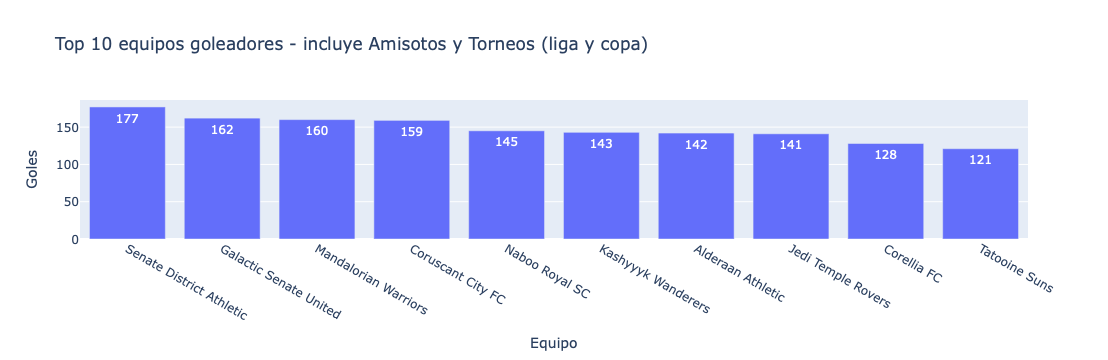

In [192]:
equipos_gol = goals.groupby('goal_scorer_team')['goal_scorer_id'].count().reset_index(name='cant_goles')
equipos_gol = equipos_gol.sort_values('cant_goles', ascending=False).head(10)

px.bar(equipos_gol, 
       x='goal_scorer_team', 
       y='cant_goles', 
       title='Top 10 equipos goleadores - incluye Amisotos y Torneos (liga y copa)',
       labels={'goal_scorer_team': 'Equipo', 'cant_goles': 'Goles'},
       text='cant_goles')

**13)** Create a histogram of the distribution of 'xg' for all goals in the Coruscant League. What shape does the distribution have? What can be inferred about the types of shots that result in goals?

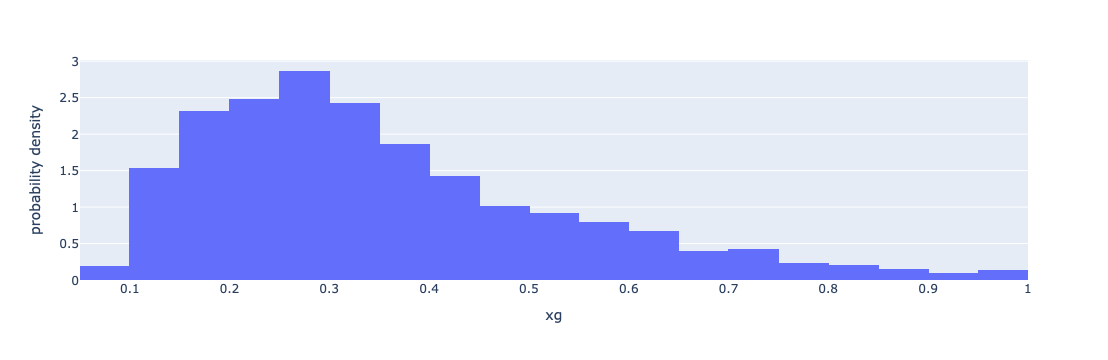

In [211]:
liga = goals [goals['tournament'] == 'Liga Coruscant']

px.histogram(liga, x='xg', nbins = 20, histnorm = 'probability density')

**Answer 13)**: The histogram shows a right-skewed distribution. The majority of goals are concentrated in low and intermediate xG values, especially between approximately 0.15 and 0.35. This indicates that many Coruscant League goals come from shots with moderate probabilities, while goals with very high xG values ​​occur less frequently. Overall, there is no dominant concentration of extremely clear chances, but rather a greater presence of goals from situations of intermediate probability.

**14)** Create a scatterplot where:
- The X-axis is `distance` (distance to the arc)
- The Y-axis is `xg`
- The points are colored according to the `period` (1st or 2nd time)

Is there any relationship between distance and xg? Does it differ between periods?

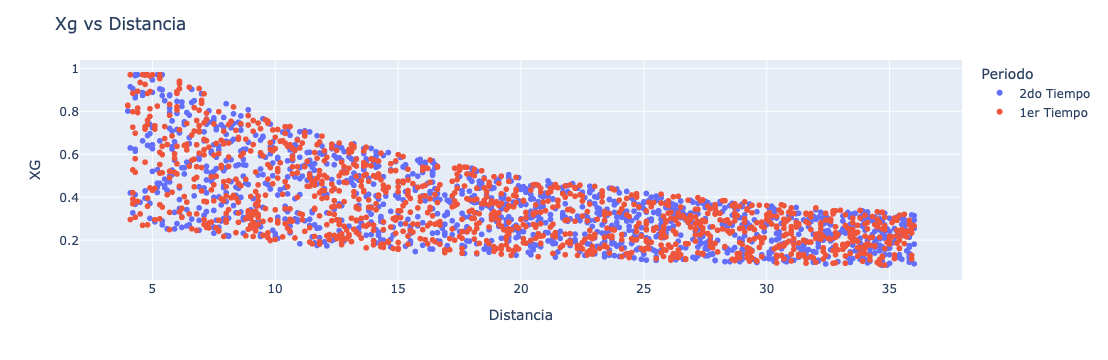

In [215]:
# Using the goals dataframe from exercise 7 (includes friendlies, league and cup matches)

scatter=px.scatter(goals, x='distance' , y='xg', color ='period')
scatter.update_layout(title='Xg vs Distancia',xaxis_title = 'Distancia', yaxis_title ='XG', legend_title='Periodo')

**Answer 14)**: A negative relationship is observed between the distance to the arc and the xG value: as the distance increases, the xG values ​​tend to be lower. This is reasonable, since shots closer to the goal tend to have a greater chance of becoming a goal.

Regarding the period, the points corresponding to the 1st half and the 2nd half appear quite mixed throughout the graph. Therefore, there is no marked difference between periods in the relationship between distance and xG. The distance to the goal seems to explain the variation in xG better than the moment of the game in which the goal was scored.

**15)** Make a lineplot showing, for the Coruscant League, how many goals were scored in the 1st half vs. the 2nd half **by match date** (group by `date` and `period`). Is there any period of the championship where you see a marked difference?

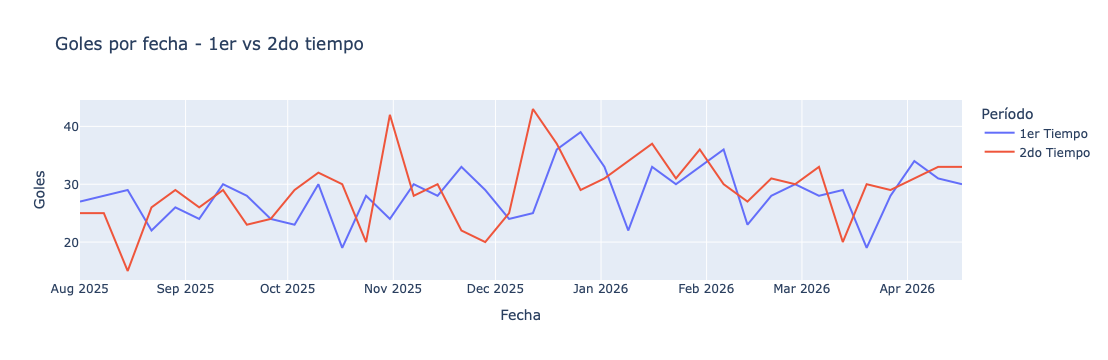

In [226]:
goles_fecha = goals[goals['tournament'] == 'Liga Coruscant'].copy()

goles_fecha['date'] = pd.to_datetime(goles_fecha['date']).dt.date
goles_fecha = goles_fecha.groupby(['date', 'period'])['goal_scorer_id'].count().reset_index(name='cant_goles')

px.line(goles_fecha,
        x='date',
        y='cant_goles',
        color='period',
        title='Goles por fecha - 1er vs 2do tiempo',
        labels={'date': 'Fecha', 'cant_goles': 'Goles', 'period': 'Período'})

**Answer 15)**: The graph does not show a consistent difference between the first and second halves throughout the entire championship. On some matchdays, more goals are scored in the first half, and on others, the opposite occurs. When comparing matchday by matchday, the second half surpasses the first half on 8 occasions, indicating a slightly higher number of matches with more goals in the second half. However, this difference does not appear to be uniform throughout the tournament; rather, there are specific peaks, especially around November and December 2025.

**16)** Calculate, for each team in the Coruscant League, its stadium capacity (`stadium_capacity` of `teams`) and the average number of goals scored per home game. Make a scatterplot with capacity on the X axis and average home goals on the Y axis. Does there seem to be a home field advantage for teams with larger stadiums?

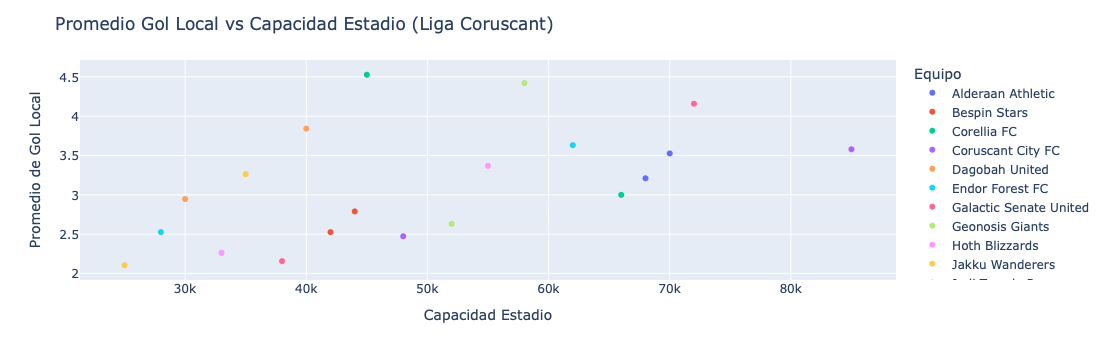

In [235]:
# Using fila_por_partido (8.d) which already filters the League => group by home_team and get average home_goals

mean_home_team = fila_por_partido.groupby('home_team')['home_goals'].mean().reset_index(name='prom_goles_local')

mean_home_team = mean_home_team.merge(teams, left_on='home_team', right_on='team_name')

fig = px.scatter(mean_home_team, x='stadium_capacity', y='prom_goles_local', color='home_team')

fig.update_layout(
    title='Promedio Gol Local vs Capacidad Estadio (Liga Coruscant)',
    xaxis_title='Capacidad Estadio',
    yaxis_title='Promedio de Gol Local',
    legend_title='Equipo')

fig.show()


**Answer 16)**: Although the trend line appears slightly upward, the dispersion of the points is high. For this reason, it cannot be concluded that teams with larger stadiums have an obvious advantage in terms of average home goals.

**17)** Make a bar graph showing the percentage of goals scored in the 1st half vs. the 2nd half, broken down by tournament. Is there a difference between tournaments?

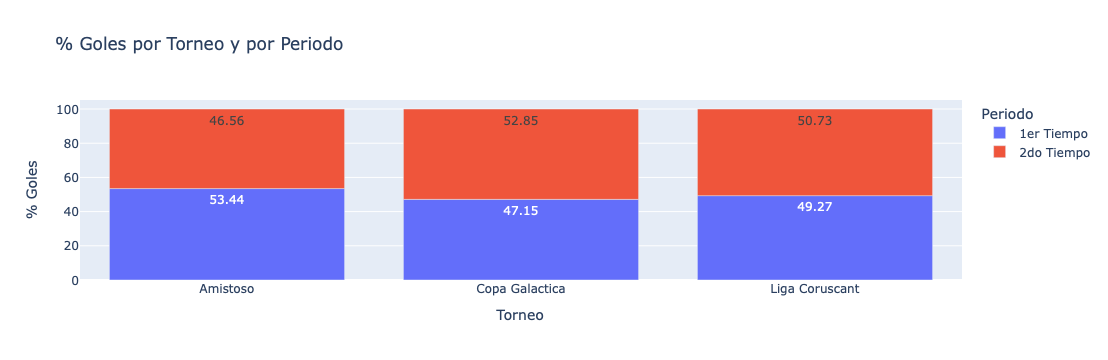

In [248]:
# uso goals (7) 
porc_goles = goals.groupby(['tournament', 'period'])['goal_scorer_id'].count().reset_index(name='cant_goles')

porc_goles['total_goles'] = porc_goles.groupby('tournament')['cant_goles'].transform('sum')

porc_goles['porcentaje_goles'] = ((porc_goles['cant_goles'] / porc_goles['total_goles']) * 100).round(2)

px.bar(porc_goles, 
       x='tournament', 
       y='porcentaje_goles', 
       title='% Goles por Torneo y por Periodo',
       text='porcentaje_goles',
       color = 'period',
       labels={'tournament': 'Torneo', 'porcentaje_goles': '% Goles', 'period': 'Periodo'}
      )

**Answer 17)**: The graph shows that the distribution of goals per period is quite balanced in the three tournaments. In the Coruscant League, the percentages are almost the same: 49.3% in the 1st half and 50.7% in the 2nd half. In the Galactic Cup, a greater proportion of goals is observed in the 2nd half, with 52.8%, while in friendlies the opposite occurs, with 53.4% ​​of goals in the 1st half.

In general, there does not seem to be a very marked difference between periods. The largest gap is observed in the friendlies and in the Galactic Cup, but even so the differences are moderate.

**18)** Free analysis: analyze, with at least one graph and a table, some relationship or insight not explored so far in this TP. They can consider at least two variables. Write the findings found.

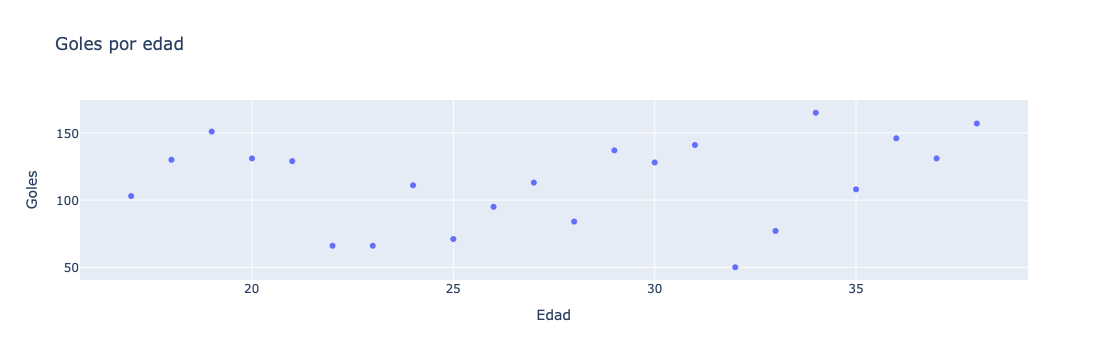

In [258]:
# 18) Age distribution of scorers — do younger or more experienced players score more goals? Considering all tournaments

goleadores_por_edad = goals.groupby('goal_scorer_id')['goal_scorer_id'].count().reset_index(name='cant_goles')

goleadores_por_edad = goleadores_por_edad.merge (players, left_on = 'goal_scorer_id', right_on = 'player_id')

goleadores_por_edad = goleadores_por_edad.groupby('player_age')['cant_goles'].sum().reset_index()

px.scatter(goleadores_por_edad, x='player_age', y='cant_goles')


px.scatter(goleadores_por_edad, x='player_age', y='cant_goles',
           title='Goles por edad',
           labels={'player_age': 'Edad', 'cant_goles': 'Goles'})


**Answer 18**: The scatter plot shows no clear relationship between age and total goals scored. Players across all age ranges (18–40) display similar scoring volumes, with no strong upward or downward trend. This suggests that in the Coruscant League, a player's age is not a determining factor in their goal-scoring output.